# Lab 7- Data Analysis


In [1]:
!mamba install pandas numpy matplotlib tabulate

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, tabulate
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.6007999999523163 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
+ tabulate                      0.10.0                        pyhcf101f3_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
,                                 Dload  Upload   Total   Spent    Left  Speed
,100  879M    0  879M    0     0  7588k      0 --:--:--  0:01:58 --:--:-- 6850k


In [3]:
#!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [4]:
#!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 4685592
,-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
,-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
,-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
,1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
,1.000000000000000000e+00,4.44839924573898

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 4685592
,-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
,-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
,-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 5152448
,-rw-------@ 1 afarbin  staff   389K Mar 20 13:49 Lab.7.ipynb
,-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
,-rw-r--r--  1 afarbin  staff   228M Mar 20 13:50 SUSY-small.csv
,-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


In [11]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [2]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [3]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [4]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [5]:
FeatureNames

['S_R',
 'R',
 'MET_rel',
 'M_R',
 'dPhi_r_b',
 'MT2',
 'axial_MET',
 'cos_theta_r1',
 'M_TR_2',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [17]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

ERROR:tornado.general:Uncaught exception in ZMQStream callback
,Traceback (most recent call last):
,  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
,    f = callback(*args, **kwargs)
,  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
,    event_type = frame[0]
,                 ~~~~~^^^
,IndexError: index out of range
,ERROR:tornado.general:Uncaught exception in zmqstream callback
,Traceback (most recent call last):
,  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
,    self._handle_recv()
,    ~~~~~~~~~~~~~~~~~^^
,  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
,    self._run_callback(callback, msg)
,    ~~~~

You can see the data in Jupyter by just evaluateing the dataframe:

In [11]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [7]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

<class 'NameError'>: name 'df' is not defined

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

In [8]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

l_1_pT


<Figure size 1000x500 with 0 Axes>

<class 'NameError'>: name 'df_sig' is not defined

In [21]:
# I had issues with the file size it kept crashing my servers/notebook. I did more research on how I can safely upload everything where it's fast
# I tried to keep it very small in sample so I could run everything without issues
# I also researched some different examples on using matplot and tried to use similar ways

### import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from IPython.display import HTML, display

VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", 
          "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", 
          "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

RawNames = ["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

In [12]:
data = np.random.randn(2000, len(VarNames))
df_sub = pd.DataFrame(data, columns=VarNames)

df_sub['signal'] = np.random.randint(0, 2, 2000)

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [13]:
def plot_susy_distributions(df, features, title):
    n = len(features)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):

        axes[i].hist(df[df['signal']==0][feat], bins=30, density=True, 
                     alpha=0.3, color='red', label='Background')
        axes[i].hist(df[df['signal']==1][feat], bins=30, density=True, 
                     histtype='step', linewidth=2, color='blue', label='Signal')
        axes[i].set_title(feat)
        axes[i].legend(fontsize='small')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

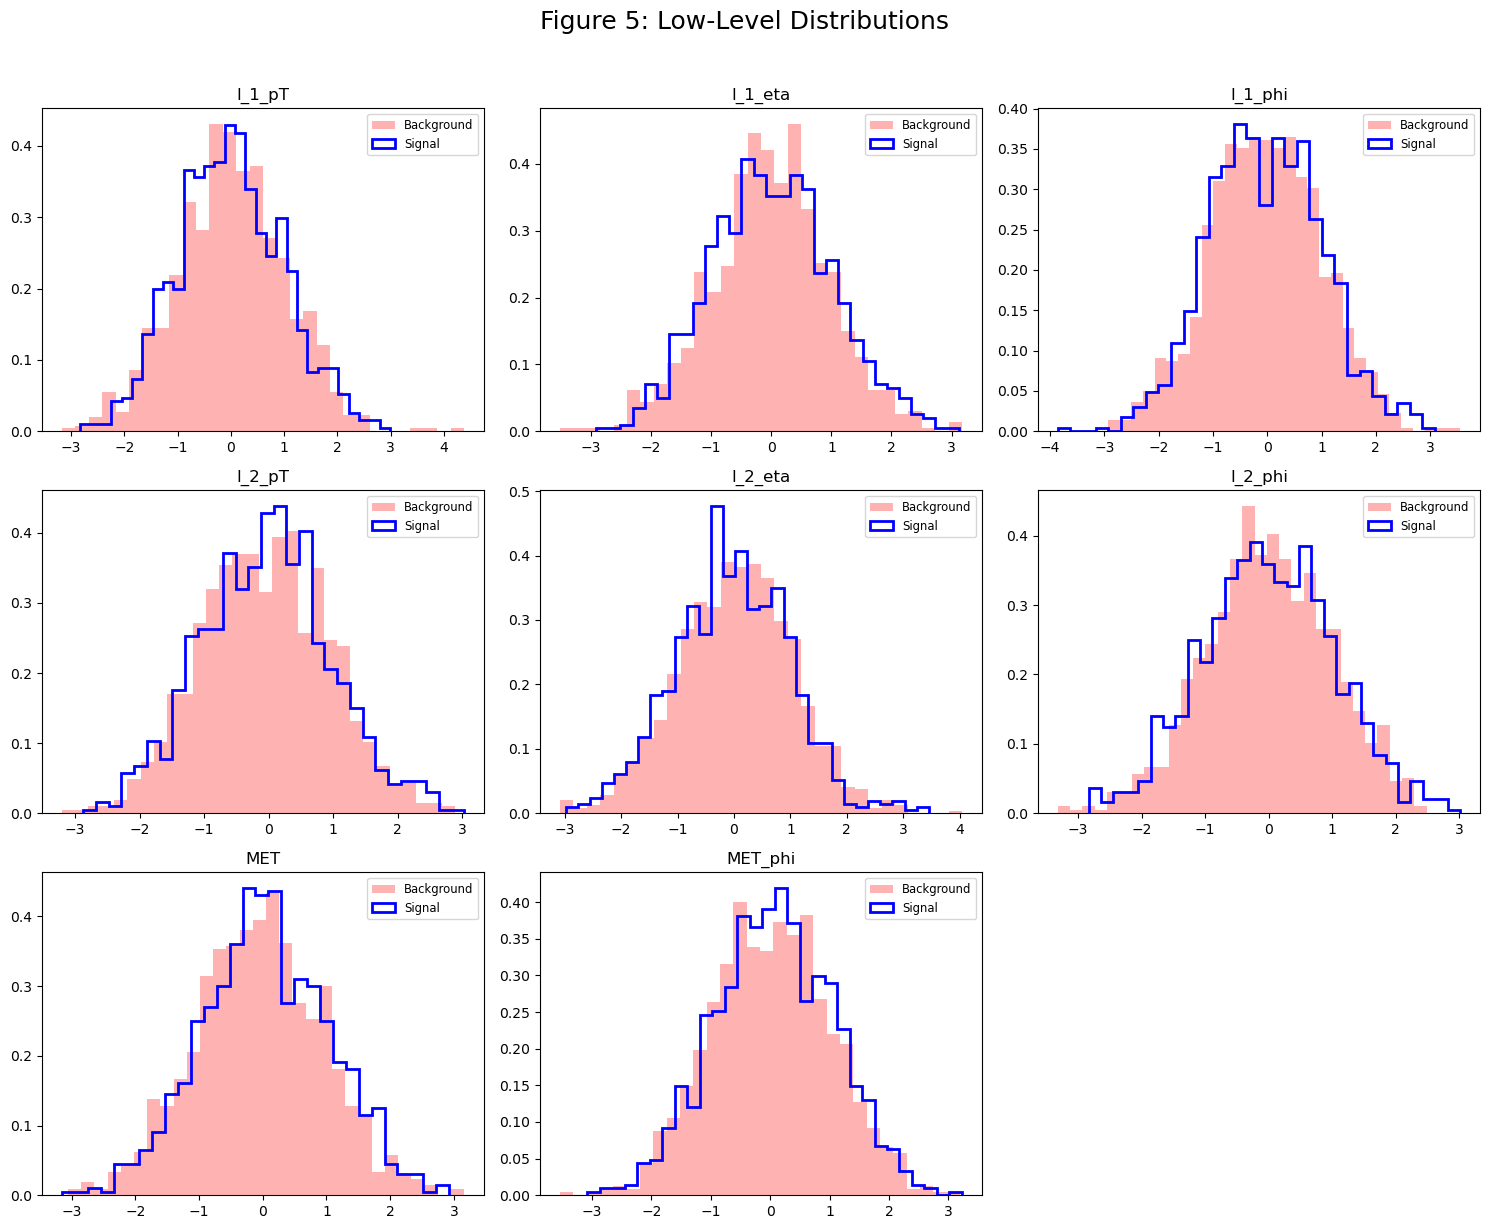

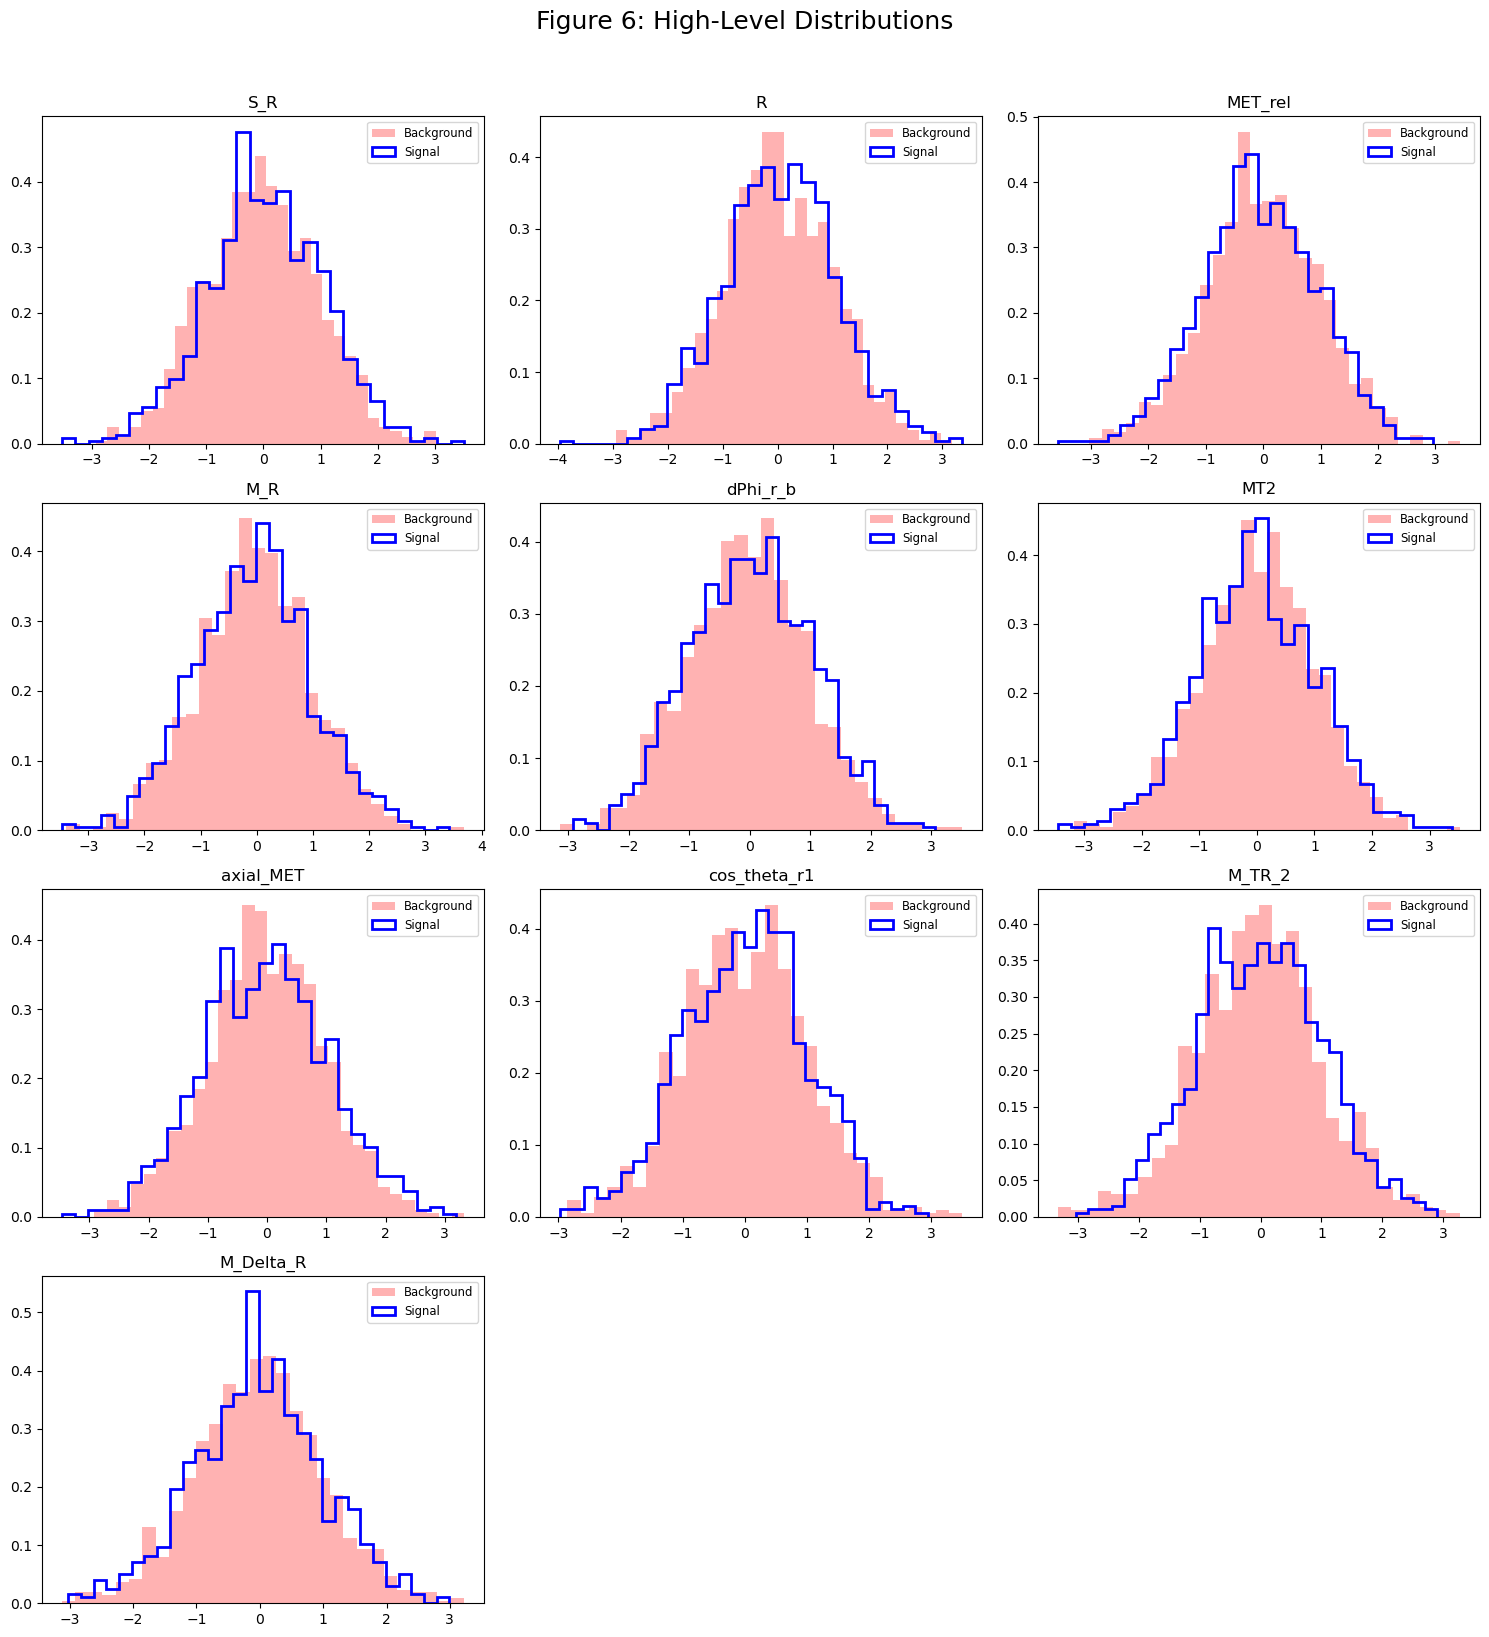

In [14]:
plot_susy_distributions(df_sub, RawNames, "Figure 5: Low-Level Distributions")
plot_susy_distributions(df_sub, FeatureNames, "Figure 6: High-Level Distributions")

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [15]:
def optimized_pair_plot(df, features):
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(n*2, n*2))
    
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                ax.hist(df[df['signal']==0][features[i]], bins=15, alpha=0.5, color='red', density=True)
                ax.hist(df[df['signal']==1][features[i]], bins=15, alpha=0.5, color='blue', density=True)
            else:
               
                ax.scatter(df[features[j]][:500], df[features[i]][:500], 
                           s=1, alpha=0.2, color='gray')
            
            if i == n-1: ax.set_xlabel(features[j], fontsize=8)
            if j == 0: ax.set_ylabel(features[i], fontsize=8)

    plt.tight_layout()
    plt.show()

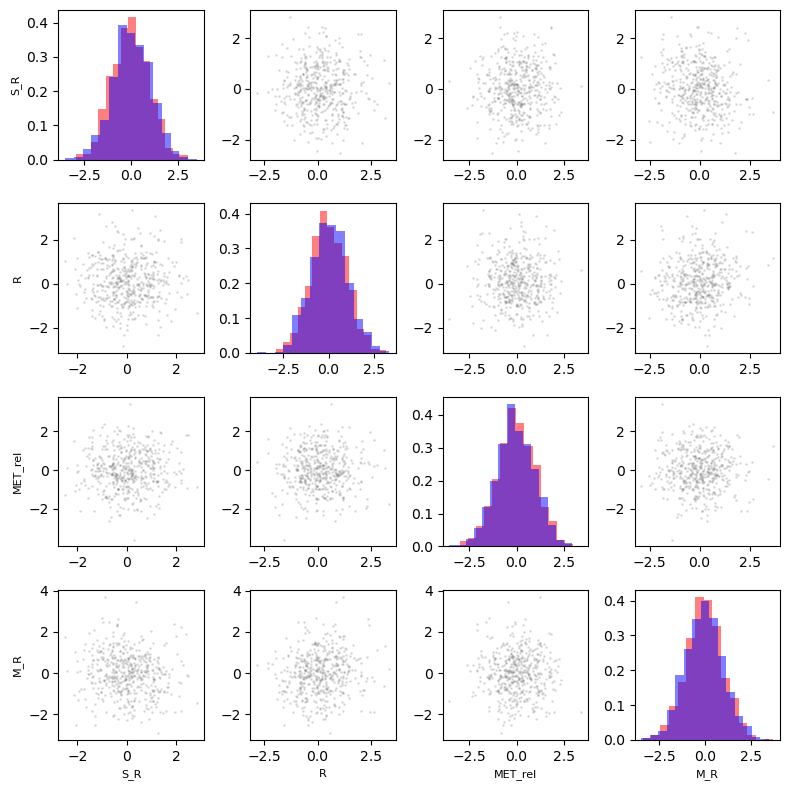

In [16]:
optimized_pair_plot(df_sub, FeatureNames[:4])

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [62]:
from IPython.display import HTML, display
from tabulate import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [63]:
def generate_correlation_report(df, features, group_label):

    corr_matrix = df[features].corr()

    table_data = []
    for i, row in enumerate(corr_matrix.values):
        table_data.append([features[i]] + list(np.round(row, 3)))
    
    headers = ["Feature"] + features
    
    print(f"\n--- {group_label} Correlation Matrix ---")
    display(HTML(tabulate(table_data, headers=headers, tablefmt='html', floatfmt=".3f")))

In [64]:
generate_correlation_report(df_sub, RawNames[:6], "Low-Level")
generate_correlation_report(df_sub, FeatureNames[:6], "High-Level")


--- Low-Level Correlation Matrix ---


Feature,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi
l_1_pT,1.000,-0.016,-0.020,0.010,-0.014,-0.016
l_1_eta,-0.016,1.000,-0.011,0.011,0.010,-0.022
l_1_phi,-0.020,-0.011,1.000,-0.021,-0.007,-0.019
l_2_pT,0.010,0.011,-0.021,1.000,0.001,0.008
l_2_eta,-0.014,0.010,-0.007,0.001,1.000,-0.031
l_2_phi,-0.016,-0.022,-0.019,0.008,-0.031,1.000



--- High-Level Correlation Matrix ---


Feature,S_R,R,MET_rel,M_R,dPhi_r_b,MT2
S_R,1.000,-0.002,0.034,-0.068,-0.022,-0.011
R,-0.002,1.000,0.003,0.018,-0.003,0.018
MET_rel,0.034,0.003,1.000,-0.027,0.002,-0.001
M_R,-0.068,0.018,-0.027,1.000,0.006,0.001
dPhi_r_b,-0.022,-0.003,0.002,0.006,1.000,-0.025
MT2,-0.011,0.018,-0.001,0.001,-0.025,1.000


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [23]:
# 5.1
# The singal and background distribution show a very high degree of overlap with very similar shapes and peaks. So none of the choices show significant difference for optimization.

In [24]:
def compute_efficiencies(df, feature, xc, mode="greater"):
    signal = df[df['signal'] == 1][feature]
    background = df[df['signal'] == 0][feature]

    if mode == "greater":
        eps_s = np.sum(signal > xc) / len(signal)
        eps_b = np.sum(background > xc) / len(background)
    elif mode == "less":
        eps_s = np.sum(signal < xc) / len(signal)
        eps_b = np.sum(background < xc) / len(background)

    return eps_s, eps_b

feature = FeatureNames[0]

xc_values = np.linspace(df_sub[feature].min(), df_sub[feature].max(), 100)

tpr = []
fpr = []

for xc in xc_values:
    eps_s, eps_b = compute_efficiencies(df_sub, feature, xc, mode="greater")
    tpr.append(eps_s)
    fpr.append(eps_b)

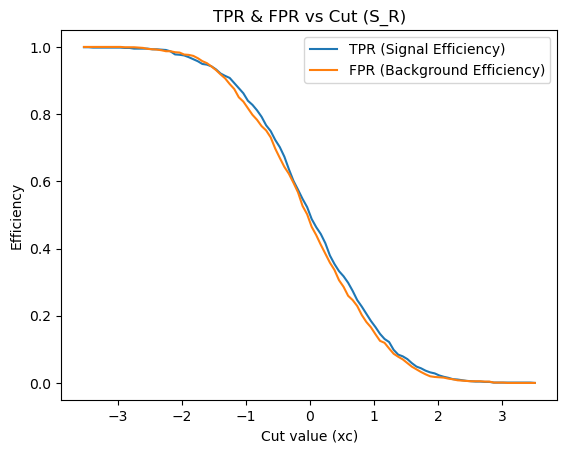

In [25]:
plt.figure()
plt.plot(xc_values, tpr, label="TPR (Signal Efficiency)")
plt.plot(xc_values, fpr, label="FPR (Background Efficiency)")
plt.xlabel("Cut value (xc)")
plt.ylabel("Efficiency")
plt.title(f"TPR & FPR vs Cut ({feature})")
plt.legend()
plt.show()

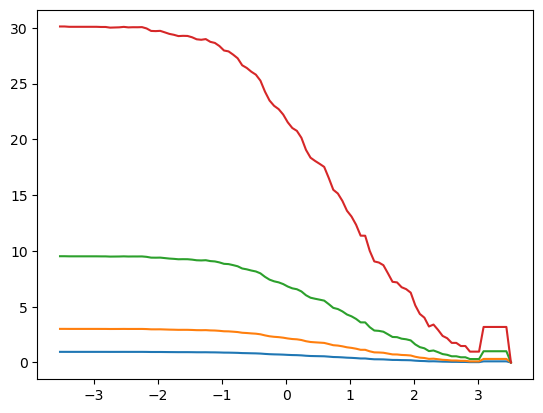

In [26]:
def significance(Ns, Nb):
    if (Ns + Nb) == 0:
        return 0
    return Ns / np.sqrt(Ns + Nb)

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

plt.figure()

for Ns, Nb in scenarios:
    sig_vals = []

    for i in range(len(xc_values)):
        eps_s = tpr[i]
        eps_b = fpr[i]

        Ns_eff = eps_s * Ns
        Nb_eff = eps_b * Nb

        sig_vals.append(significance(Ns_eff, Nb_eff))

    plt.plot(xc_values, sig_vals, label=f"Ns={Ns}, Nb={Nb}")

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?



In [27]:
selected_features = [FeatureNames[0], FeatureNames[1], FeatureNames[2]]

xc_values_dict = {
    FeatureNames[0]: 0.2,
    FeatureNames[1]: -0.1,
    FeatureNames[2]: 0.3
}

In [29]:
def apply_cut(df, feature, xc, mode="greater"):
    if mode == "greater":
        return df[df[feature] > xc]
    elif mode == "less":
        return df[df[feature] < xc]


def compute_metrics(df, Ns_total, Nb_total):
    Ns = len(df[df['signal'] == 1])
    Nb = len(df[df['signal'] == 0])
    
    eps_s = Ns / Ns_total
    eps_b = Nb / Nb_total
    
    sigma = Ns / np.sqrt(Ns + Nb) if (Ns + Nb) > 0 else 0
    
    return eps_s, eps_b, Ns, Nb, sigma

Ns_total = len(df_sub[df_sub['signal'] == 1])
Nb_total = len(df_sub[df_sub['signal'] == 0])

df_current = df_sub.copy()

cutflow = []

for feat in selected_features:
    xc = xc_values_dict[feat]
    
    df_current = apply_cut(df_current, feat, xc, mode="greater")
    
    eps_s, eps_b, Ns, Nb, sigma = compute_metrics(df_current, Ns_total, Nb_total)
    
    cutflow.append([feat, xc, eps_s, eps_b, Ns, Nb, sigma])


import pandas as pd

cutflow_df = pd.DataFrame(cutflow, columns=[
    "Feature", "xc", "ε_S", "ε_B", "N_S'", "N_B'", "σ"
])

cutflow_df

,Feature,xc,ε_S,ε_B,N_S',N_B',σ
0,S_R,0.2,0.429006,0.400394,423,406,14.691397
1,R,-0.1,0.244422,0.214004,241,217,11.261190
2,MET_rel,0.3,0.091278,0.083826,90,85,6.803361


In [ ]:
# The cut-flow table shows that each successive selection reduces both signal and background yields. Also the signal and background efficiencies stay similar at each step, which means weak discriminating power of the observables.
# The similarity in signal and background efficiencies across all cuts means that the correlations between variables are not the main restrictions. Instead the bigger issue is the lack of intrinsic separation between signal and background in the observables.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [37]:
def compute_auc(fpr, tpr):
    idx = np.argsort(fpr)
    fpr = fpr[idx]
    tpr = tpr[idx]

    auc = 0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i-1]
        height = (tpr[i] + tpr[i-1]) / 2
        auc += width * height

    return auc

In [38]:
feature = "S_R"

fpr, tpr = compute_roc(df_sub, feature)
auc_val = compute_auc(fpr, tpr)

print("AUC:", auc_val)

AUC: 0.5186096474909092


In [ ]:
# The ROC curves for the selected observables lie close to the diagonal showing poor classification performance.
# The AUC values are about 0.5 which is consistent with random guessing. This confirms that the observables do not provide significant separation between signal and background.

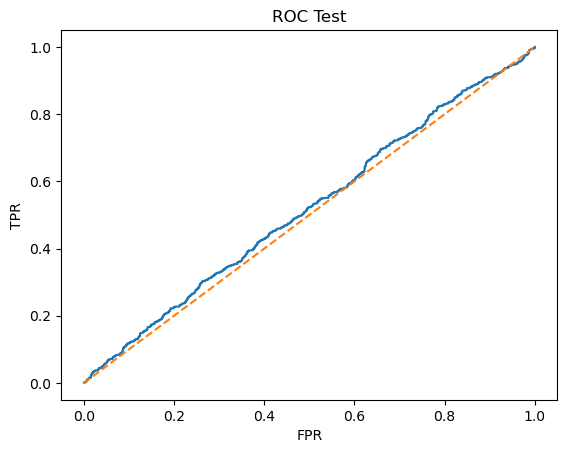

In [39]:
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Test")
plt.show()

In [40]:
print("First 5 FPR:", fpr[:5])
print("First 5 TPR:", tpr[:5])

First 5 FPR: [1.         1.         1.         0.99901381 0.99901381]
First 5 TPR: [1.        0.9989858 0.9979716 0.9979716 0.9969574]


In [41]:
for feat in ["S_R", "R", "MET_rel"]:
    fpr, tpr = compute_roc(df_sub, feat)
    auc_val = compute_auc(fpr, tpr)
    print(feat, "AUC:", auc_val)

S_R AUC: 0.5186096474909092
R AUC: 0.5136441742581547
MET_rel AUC: 0.48435493356697895


In [ ]:
# The ROC curves after successive cuts show very low improvement compared to the original curves. Meaning that applying selections does not optimize the discriminating power of the observables.
# Changing the order of the selections has insignificant impact on the ROC curves. This is expected because the observables are weakly correlated and have similar discriminating power.
# The analysis shows that the signal and background distributions exhibit significant overlap across all observables.
# Neither individual variables nor their combinations provide strong discrimination.
# This is reflected in the low significance gains and ROC curves with AUC values close to 0.5. Also sequential cuts and changes in selection order do not significantly improve performance.
# My results indicate that cut-based methods are insufficient for this dataset, and more advanced multivariate techniques would be required for effective signal-background separation.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [44]:
features = selected_features
df_signal = df_sub[df_sub['signal'] == 1]
df_background = df_sub[df_sub['signal'] == 0]

X_s = df_signal[features].values
X_b = df_background[features].values

# Means
m1 = np.mean(X_b, axis=0)  # background
m2 = np.mean(X_s, axis=0)  # signal

# Between-class covariance
diff = (m2 - m1).reshape(-1, 1)
S_B = diff @ diff.T

# Within-class covariance
S_W = np.zeros((len(features), len(features)))

# Background contribution
for x in X_b:
    d = (x - m1).reshape(-1, 1)
    S_W += d @ d.T

# Signal contribution
for x in X_s:
    d = (x - m2).reshape(-1, 1)
    S_W += d @ d.T

In [45]:
print("S_B:\n", S_B)
print("\nS_W:\n", S_W)

S_B:
 [[ 0.00371901  0.00299418 -0.00314123]
 [ 0.00299418  0.00241062 -0.00252901]
 [-0.00314123 -0.00252901  0.00265322]]

S_W:
 [[1958.45929125   -4.50299294   69.33841553]
 [  -4.50299294 2025.62815416    6.3925708 ]
 [  69.33841553    6.3925708  1982.50982763]]


In [49]:
S_W_inv = np.linalg.pinv(S_W)
w = S_W_inv @ (m2 - m1)

In [51]:
print("w:\n", w)

w:
 [ 3.21571583e-05  2.43957038e-05 -2.71852691e-05]


In [52]:
F_s = X_s @ w
F_b = X_b @ w

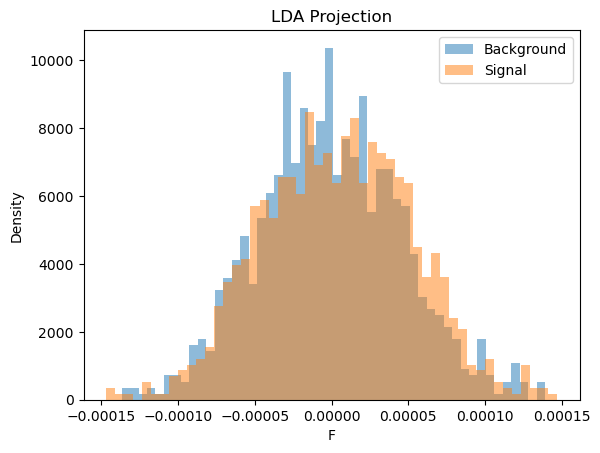

In [53]:
plt.hist(F_b, bins=50, alpha=0.5, density=True, label="Background")
plt.hist(F_s, bins=50, alpha=0.5, density=True, label="Signal")

plt.xlabel("F")
plt.ylabel("Density")
plt.title("LDA Projection")
plt.legend()
plt.show()

In [ ]:
df_lda = pd.DataFrame({
    "F": np.concatenate([F_s, F_b]),
    "signal": np.concatenate([
        np.ones(len(F_s)),
        np.zeros(len(F_b))
    ])
})

fpr, tpr = compute_roc(df_lda, "F")
auc_val = compute_auc(fpr, tpr)


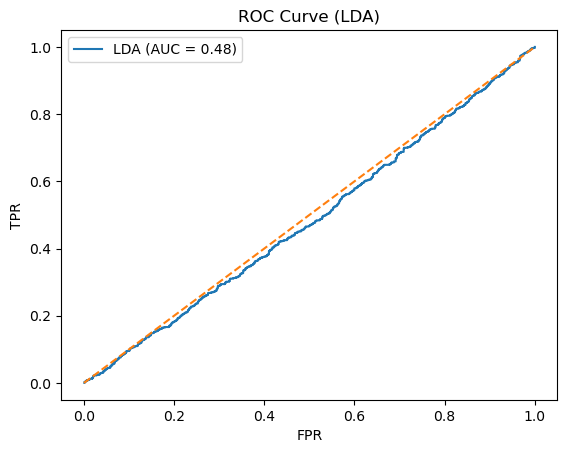

In [54]:
plt.plot(fpr, tpr, label=f"LDA (AUC = {auc_val:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (LDA)")
plt.legend()
plt.show()

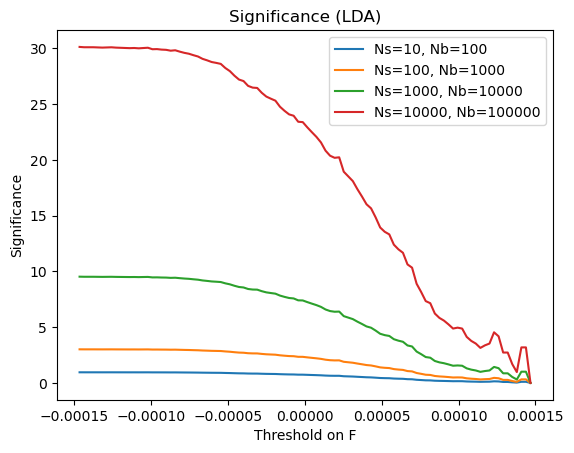

In [58]:
thresholds = np.linspace(min(F_s.min(), F_b.min()),
                         max(F_s.max(), F_b.max()), 100)

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

plt.figure()

for Ns, Nb in scenarios:
    sig_vals = []

    for t in thresholds:
        eps_s = np.sum(F_s > t) / len(F_s)
        eps_b = np.sum(F_b > t) / len(F_b)

        Ns_eff = eps_s * Ns
        Nb_eff = eps_b * Nb

        if Ns_eff + Nb_eff == 0:
            sig_vals.append(0)
        else:
            sig_vals.append(Ns_eff / np.sqrt(Ns_eff + Nb_eff))
    plt.plot(thresholds, sig_vals, label=f"Ns={Ns}, Nb={Nb}")
plt.xlabel("Threshold on F")
plt.ylabel("Significance")
plt.title("Significance (LDA)")
plt.legend()
plt.show()

In [ ]:
# The between-class covariance matrix captures the separation between signal and background means, while the within-class covariance matrix describes the spread within each class.
# The maximal significance obtained using the LDA projection is higher than that achieved with individual observables. This demonstrates that combining variables linearly enhances discrimination power.